<a href="https://colab.research.google.com/github/ChinthaDeepak96/Cataract-Prediction-using-CNN-models-/blob/main/Cataract_Prediction_(kadr).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
andrewmvd_ocular_disease_recognition_odir5k_path = kagglehub.dataset_download('andrewmvd/ocular-disease-recognition-odir5k')

print('Data source import complete.')


Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Data source import complete.


---

<h1 style="text-align: center;font-size: 40px;">Cataract Prediction using vgg19</h1>

---

<h3>Dataset Information:</h3>
Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords from doctors.This dataset is meant to represent ‘‘real-life’’ set of patient information collected by Shanggong Medical Technology Co., Ltd. from different hospitals/medical centers in China. In these institutions, fundus images are captured by various cameras in the market, such as Canon, Zeiss and Kowa, resulting into varied image resolutions.Annotations were labeled by trained human readers with quality control management. They classify patient into eight labels including:

- Normal (N),
- Diabetes (D),
- Glaucoma (G),
- Cataract (C),
- Age related Macular Degeneration (A),
- Hypertension (H),
- Pathological Myopia (M),
- Other diseases/abnormalities (O)

- Here i'm going to make a model which is going to  predict an image is belongs to Normal or Cataract category!

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/2704_left.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/734_left.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/1208_right.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/4401_right.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/2070_right.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/728_right.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/534_left.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/4487_right.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/1494_left.jpg
/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/342_right.jpg
/kaggle

In [ ]:
!pip install tensorflow
!pip install scikit-learn
!pip install mlxtend

In [ ]:
df = pd.read_csv("/kaggle/input/ocular-disease-recognition-odir5k/full_df.csv")
df.head(3)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg


> <h3> Extracting Cataract & Normal information from the Dataset </h3>

In [ ]:
def has_cataract(text):
    if "cataract" in text:
        return 1
    else:
        return 0

In [ ]:
df["left_cataract"] = df["Left-Diagnostic Keywords"].apply(lambda x: has_cataract(x))
df["right_cataract"] = df["Right-Diagnostic Keywords"].apply(lambda x: has_cataract(x))

In [ ]:
left_cataract = df.loc[(df.C ==1) & (df.left_cataract == 1)]["Left-Fundus"].values
left_cataract[:15]

array(['0_left.jpg', '81_left.jpg', '103_left.jpg', '119_left.jpg',
       '254_left.jpg', '294_left.jpg', '330_left.jpg', '448_left.jpg',
       '465_left.jpg', '477_left.jpg', '553_left.jpg', '560_left.jpg',
       '594_left.jpg', '611_left.jpg', '625_left.jpg'], dtype=object)

In [ ]:
right_cataract = df.loc[(df.C ==1) & (df.right_cataract == 1)]["Right-Fundus"].values
right_cataract[:15]

array(['24_right.jpg', '81_right.jpg', '112_right.jpg', '188_right.jpg',
       '218_right.jpg', '345_right.jpg', '354_right.jpg', '477_right.jpg',
       '553_right.jpg', '560_right.jpg', '625_right.jpg', '726_right.jpg',
       '769_right.jpg', '949_right.jpg', '955_right.jpg'], dtype=object)

In [ ]:
print("Number of images in left cataract: {}".format(len(left_cataract)))
print("Number of images in right cataract: {}".format(len(right_cataract)))

Number of images in left cataract: 304
Number of images in right cataract: 290


>Normal Images

In [ ]:
left_normal = df.loc[(df.C ==0) & (df["Left-Diagnostic Keywords"] == "normal fundus")]["Left-Fundus"].sample(250,random_state=42).values
right_normal = df.loc[(df.C ==0) & (df["Right-Diagnostic Keywords"] == "normal fundus")]["Right-Fundus"].sample(250,random_state=42).values
right_normal[:15]

array(['2964_right.jpg', '680_right.jpg', '500_right.jpg',
       '2368_right.jpg', '2820_right.jpg', '2769_right.jpg',
       '2696_right.jpg', '2890_right.jpg', '940_right.jpg',
       '2553_right.jpg', '3371_right.jpg', '3042_right.jpg',
       '919_right.jpg', '3427_right.jpg', '379_right.jpg'], dtype=object)

In [ ]:
cataract = np.concatenate((left_cataract,right_cataract),axis=0)
normal = np.concatenate((left_normal,right_normal),axis=0)

In [ ]:
print(len(cataract),len(normal))

594 500


><h3>Creating Dataset from images</h3>

In [ ]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
dataset_dir = "/kaggle/input/ocular-disease-recognition-odir5k/preprocessed_images/"
image_size=224
labels = []
dataset = []
def create_dataset(image_category,label):
    for img in tqdm(image_category):
        image_path = os.path.join(dataset_dir,img)
        try:
            image = cv2.imread(image_path,cv2.IMREAD_COLOR)
            image = cv2.resize(image,(image_size,image_size))
        except:
            continue

        dataset.append([np.array(image),np.array(label)])
    random.shuffle(dataset)
    return dataset


In [ ]:
dataset = create_dataset(cataract,1)

100%|██████████| 594/594 [00:06<00:00, 91.23it/s] 


In [ ]:
len(dataset)

588

In [ ]:
dataset = create_dataset(normal,0)

100%|██████████| 500/500 [00:07<00:00, 69.20it/s]


In [ ]:
len(dataset)

1088

><h3>Let's see some images</h3>

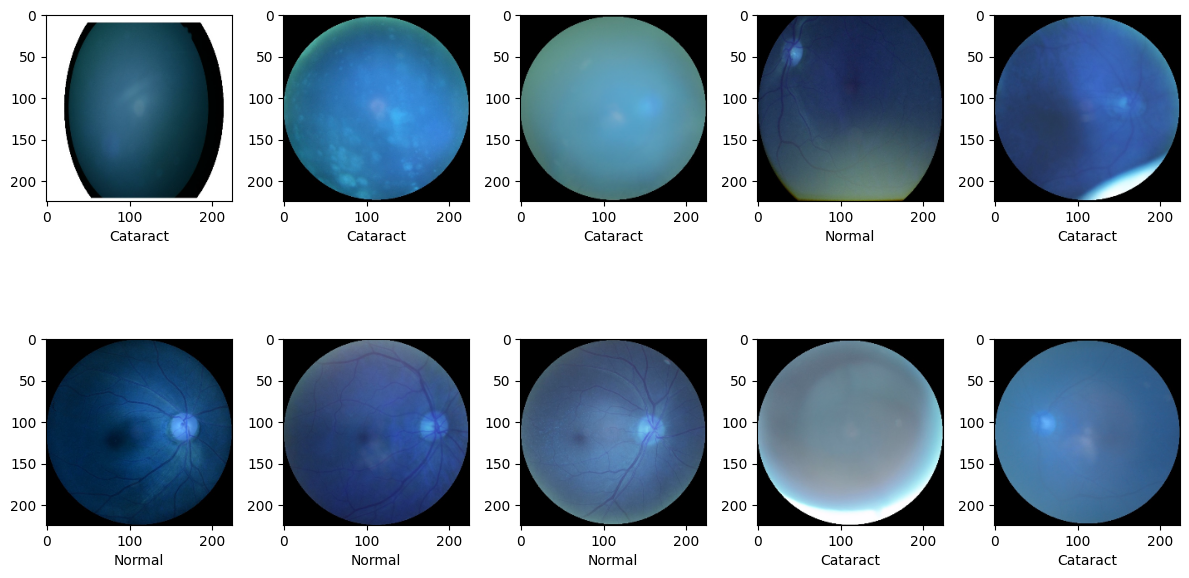

In [ ]:
plt.figure(figsize=(12,7))
for i in range(10):
    sample = random.choice(range(len(dataset)))
    image = dataset[sample][0]
    category = dataset[sample][1]
    if category== 0:
        label = "Normal"
    else:
        label = "Cataract"
    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.xlabel(label)
plt.tight_layout()

><h3>Dividing dataset into x(features) & y(target)</h3>

In [ ]:
x = np.array([i[0] for i in dataset]).reshape(-1,image_size,image_size,3)
y = np.array([i[1] for i in dataset])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

><h3>Creating Model</h3>

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
vgg = VGG19(weights="imagenet",include_top = False,input_shape=(image_size,image_size,3))

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
for layer in vgg.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense
model = Sequential()
model.add(vgg)
model.add(Flatten())
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,049,473 (76.48 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Define image size
image_size = 224

# --- MobileNetV2 ---
mobilenet_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(image_size, image_size, 3))
for layer in mobilenet_base.layers:
    layer.trainable = False
mobilenet_model = Sequential([
    mobilenet_base,
    Flatten(),
    Dense(1, activation="sigmoid")
])
mobilenet_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
mobilenet_model.summary()  # Print MobileNetV2 summary

# --- ResNet50 ---
resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(image_size, image_size, 3))
for layer in resnet_base.layers:
    layer.trainable = False
resnet_model = Sequential([
    resnet_base,
    Flatten(),
    Dense(1, activation="sigmoid")
])
resnet_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
resnet_model.summary()  # Print ResNet50 summary



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        62,721 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,320,705 (8.85 MB)

 Trainable params: 62,721 (245.00 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │       100,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,688,065 (90.36 MB)

 Trainable params: 100,353 (392.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
checkpoint = ModelCheckpoint("vgg19.h5",monitor="val_acc",verbose=1,save_best_only=True,
                             save_weights_only=False,save_freq='epoch') # Change 'period' to 'save_freq' and set it to 'epoch' to save every epoch
earlystop = EarlyStopping(monitor="val_acc",patience=5,verbose=1, mode='max') # Added mode='max'

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


# Define callbacks
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", verbose=1,
                             save_best_only=True, mode='max', save_freq='epoch')
earlystop = EarlyStopping(monitor="val_accuracy", patience=5, verbose=1, mode='max')

# Train MobileNetV2
mobilenet_history = mobilenet_model.fit(x_train, y_train, batch_size=32, epochs=15,
                                       validation_data=(x_test, y_test), verbose=1,
                                       callbacks=[checkpoint, earlystop])

# Train ResNet50
resnet_history = resnet_model.fit(x_train, y_train, batch_size=32, epochs=15,
                                 validation_data=(x_test, y_test), verbose=1,
                                 callbacks=[checkpoint, earlystop])



Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6104 - loss: 3.3558
Epoch 1: val_accuracy improved from -inf to 0.75688, saving model to best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.6134 - loss: 3.3272 - val_accuracy: 0.7569 - val_loss: 1.7311
Epoch 2/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8408 - loss: 1.1034
Epoch 2: val_accuracy improved from 0.75688 to 0.88991, saving model to best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8424 - loss: 1.0739 - val_accuracy: 0.8899 - val_loss: 0.3808
Epoch 3/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8967 - loss: 0.3994
Epoch 3: val_accuracy did not improve from 0.88991
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8975 - loss: 0.3954 - val_accuracy: 0.8807 - val_loss: 0.3960
Epoch 4/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9357 - loss: 0.1351
Epoch 4: val_accuracy improved from 0.88991 to 0.93578, saving model to best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9363 - loss: 0.1347 - val_accuracy: 0.9358 - val_loss: 0.2786
Epoch 5/15
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9652 - loss: 0.0772
Epoch 5: val_accuracy did not improve from 0.93578
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9661 - loss: 0.0763 - val_accuracy: 0.9266 - val_loss: 0.2908
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9671 - loss: 0.0770
Epoch 6: val_accuracy did not improve from 0.93578
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9668 - loss: 0.0776 - val_accuracy: 0.9174 - val_loss: 0.3003
Epoch 7/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9954 - loss: 0.0349
Epoch 7: val_accuracy improved from 0.93578 to 0.94954, saving model to best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9952 - loss: 0.0345 - val_accuracy: 0.9495 - val_loss: 0.2553
Epoch 8/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9933 - loss: 0.0226
Epoch 8: val_accuracy did not improve from 0.94954
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9935 - loss: 0.0223 - val_accuracy: 0.9404 - val_loss: 0.2642
Epoch 9/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9997 - loss: 0.0112
Epoch 9: val_accuracy improved from 0.94954 to 0.95872, saving model to best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9997 - loss: 0.0111 - val_accuracy: 0.9587 - val_loss: 0.2399
Epoch 10/15
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0073
Epoch 10: val_accuracy did not improve from 0.95872
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.9495 - val_loss: 0.2432
Epoch 11/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0069
Epoch 11: val_accuracy did not improve from 0.95872
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.9541 - val_loss: 0.2420
Epoch 12/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0050
Epoch 12: val_accuracy did not improve from 0.95872
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.9541 - val_loss: 0.2267
Epoch 13/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0047
Epoch 13: val_accuracy did not impro

28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.9682 - loss: 0.2213 - val_accuracy: 0.9725 - val_loss: 0.1749
Epoch 3/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9988 - loss: 0.0148
Epoch 3: val_accuracy improved from 0.97248 to 0.99083, saving model to best_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9987 - loss: 0.0164 - val_accuracy: 0.9908 - val_loss: 0.1336
Epoch 4/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9972 - loss: 0.0111
Epoch 4: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.9972 - loss: 0.0111 - val_accuracy: 0.9633 - val_loss: 0.1894
Epoch 5/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9982 - loss: 0.0068
Epoch 5: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9982 - loss: 0.0069 - val_accuracy: 0.9817 - val_loss: 0.1616
Epoch 6/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.0036
Epoch 6: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9817 - val_loss: 0.1658
Epoch 7/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 3.9917e-04
Epoch 7: val_accuracy did not improve

In [ ]:
history = model.fit(x_train,y_train,batch_size=32,epochs=15,validation_data=(x_test,y_test),
                    verbose=1,callbacks=[checkpoint,earlystop])

Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.7579 - loss: 3.9061
Epoch 1: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 735ms/step - accuracy: 0.7616 - loss: 3.8420 - val_accuracy: 0.9404 - val_loss: 0.9296
Epoch 2/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9477 - loss: 0.7288
Epoch 2: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 282ms/step - accuracy: 0.9483 - loss: 0.7143 - val_accuracy: 0.9450 - val_loss: 0.3531
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9762 - loss: 0.0867
Epoch 3: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.9764 - loss: 0.0869 - val_accuracy: 0.9725 - val_loss: 0.2448
Epoch 4/15
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9879 - loss: 0.0560
Epoch 4: val_accuracy did not improve from 0.99083
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.9868 - loss: 0.0610 - val_accuracy: 0.9725 -

In [ ]:
# Evaluate the models on the test set
vgg19_loss, vgg19_accuracy = model.evaluate(x_test, y_test, verbose=0)
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(x_test, y_test, verbose=0)
resnet_loss, resnet_accuracy = resnet_model.evaluate(x_test, y_test, verbose=0)

print("VGG19 - Accuracy:", vgg19_accuracy)
print("VGG19 - Loss:", vgg19_loss)

print("MobileNetV2 - Accuracy:", mobilenet_accuracy)
print("MobileNetV2 - Loss:", mobilenet_loss)

print("ResNet50 - Accuracy:", resnet_accuracy)
print("ResNet50 - Loss:", resnet_loss)

VGG19 - Accuracy: 0.9724770784378052
VGG19 - Loss: 0.21276697516441345
MobileNetV2 - Accuracy: 0.9541284441947937
MobileNetV2 - Loss: 0.23383110761642456
ResNet50 - Accuracy: 0.9862385392189026
ResNet50 - Loss: 0.11961647868156433


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- VGG19 ---
y_pred_vgg19 = model.predict(x_test)
y_pred_vgg19 = (y_pred_vgg19 > 0.5).astype(int)  # Convert probabilities to class labels
print("VGG19 - Accuracy:", accuracy_score(y_test, y_pred_vgg19))
print("VGG19 - Classification Report:\n", classification_report(y_test, y_pred_vgg19))
print("VGG19 - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vgg19))

# --- MobileNetV2 ---
y_pred_mobilenet = mobilenet_model.predict(x_test)
y_pred_mobilenet = (y_pred_mobilenet > 0.5).astype(int)
print("MobileNetV2 - Accuracy:", accuracy_score(y_test, y_pred_mobilenet))
print("MobileNetV2 - Classification Report:\n", classification_report(y_test, y_pred_mobilenet))
print("MobileNetV2 - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mobilenet))

# --- ResNet50 ---
y_pred_resnet = resnet_model.predict(x_test)
y_pred_resnet = (y_pred_resnet > 0.5).astype(int)
print("ResNet50 - Accuracy:", accuracy_score(y_test, y_pred_resnet))
print("ResNet50 - Classification Report:\n", classification_report(y_test, y_pred_resnet))
print("ResNet50 - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_resnet))

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step
VGG19 - Accuracy: 0.9724770642201835
VGG19 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        96
           1       0.97      0.98      0.98       122

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218

VGG19 - Confusion Matrix:
 [[ 92   4]
 [  2 120]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 528ms/step
MobileNetV2 - Accuracy: 0.9541284403669725
MobileNetV2 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        96
           1       0.94      0.98      0.96       122

    accuracy                           0.95       218
   macro avg       0.96      0.95      0.95       218
weighted avg       0.96      0.95      0.95       218

MobileNetV2 - Confusion Matrix:
 [[ 88   8]
 [  2 120]]


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 687ms/step
ResNet50 - Accuracy: 0.9862385321100917
ResNet50 - Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98        96
           1       0.98      0.99      0.99       122

    accuracy                           0.99       218
   macro avg       0.99      0.99      0.99       218
weighted avg       0.99      0.99      0.99       218

ResNet50 - Confusion Matrix:
 [[ 94   2]
 [  1 121]]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- VGG19 ---
y_pred_vgg19 = model.predict(x_test)
y_pred_vgg19 = (y_pred_vgg19 > 0.5).astype(int)  # Convert probabilities to class labels

# Calculate and print accuracy
vgg19_accuracy = accuracy_score(y_test, y_pred_vgg19)
print("VGG19 - Accuracy:", vgg19_accuracy)

# Print classification report
print("VGG19 - Classification Report:\n", classification_report(y_test, y_pred_vgg19))

# --- MobileNetV2 ---
y_pred_mobilenet = mobilenet_model.predict(x_test)
y_pred_mobilenet = (y_pred_mobilenet > 0.5).astype(int)
mobilenet_accuracy = accuracy_score(y_test, y_pred_mobilenet)
print("MobileNetV2 - Accuracy:", mobilenet_accuracy)
print("MobileNetV2 - Classification Report:\n", classification_report(y_test, y_pred_mobilenet))

# --- ResNet50 ---
y_pred_resnet = resnet_model.predict(x_test)
y_pred_resnet = (y_pred_resnet > 0.5).astype(int)
resnet_accuracy = accuracy_score(y_test, y_pred_resnet)
print("ResNet50 - Accuracy:", resnet_accuracy)
print("ResNet50 - Classification Report:\n", classification_report(y_test, y_pred_resnet))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
VGG19 - Accuracy: 0.9724770642201835
VGG19 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        96
           1       0.97      0.98      0.98       122

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
MobileNetV2 - Accuracy: 0.9541284403669725
MobileNetV2 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        96
           1       0.94      0.98      0.96       122

    accuracy                           0.95       218
   macro avg       0.96      0.95      0.95       218
weighted avg       0.96      0.95      0.95       218

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
ResNet50 - Accuracy: 0.9862385321100917
ResNet50 - Classification Report:
       

In [ ]:
import time
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- VGG19 ---
start_time = time.time()
y_pred_vgg19 = model.predict(x_test)
end_time = time.time()
vgg19_inference_time = end_time - start_time

y_pred_vgg19 = (y_pred_vgg19 > 0.5).astype(int)
vgg19_accuracy = accuracy_score(y_test, y_pred_vgg19)
vgg19_loss = model.evaluate(x_test, y_test, verbose=0)[0]  # Get loss from evaluation

print("VGG19 - Accuracy:", vgg19_accuracy)
print("VGG19 - Loss:", vgg19_loss)
print("VGG19 - Inference Time:", vgg19_inference_time)
print("VGG19 - Classification Report:\n", classification_report(y_test, y_pred_vgg19))

# --- MobileNetV2 ---
start_time = time.time()
y_pred_mobilenet = mobilenet_model.predict(x_test)
end_time = time.time()
mobilenet_inference_time = end_time - start_time

y_pred_mobilenet = (y_pred_mobilenet > 0.5).astype(int)
mobilenet_accuracy = accuracy_score(y_test, y_pred_mobilenet)
mobilenet_loss = mobilenet_model.evaluate(x_test, y_test, verbose=0)[0]

print("MobileNetV2 - Accuracy:", mobilenet_accuracy)
print("MobileNetV2 - Loss:", mobilenet_loss)
print("MobileNetV2 - Inference Time:", mobilenet_inference_time)
print("MobileNetV2 - Classification Report:\n", classification_report(y_test, y_pred_mobilenet))

# --- ResNet50 ---
start_time = time.time()
y_pred_resnet = resnet_model.predict(x_test)
end_time = time.time()
resnet_inference_time = end_time - start_time

y_pred_resnet = (y_pred_resnet > 0.5).astype(int)
resnet_accuracy = accuracy_score(y_test, y_pred_resnet)
resnet_loss = resnet_model.evaluate(x_test, y_test, verbose=0)[0]

print("ResNet50 - Accuracy:", resnet_accuracy)
print("ResNet50 - Loss:", resnet_loss)
print("ResNet50 - Inference Time:", resnet_inference_time)
print("ResNet50 - Classification Report:\n", classification_report(y_test, y_pred_resnet))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
VGG19 - Accuracy: 0.9724770642201835
VGG19 - Loss: 0.21276697516441345
VGG19 - Inference Time: 1.4109845161437988
VGG19 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        96
           1       0.97      0.98      0.98       122

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
MobileNetV2 - Accuracy: 0.9541284403669725
MobileNetV2 - Loss: 0.23383110761642456
MobileNetV2 - Inference Time: 0.36947178840637207
MobileNetV2 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        96
           1       0.94      0.98      0.96       122

    accuracy                           0.95       218
   macro avg       0.96      0.95      0.95       218
weighte

In [ ]:
from sklearn.metrics import classification_report

# --- VGG19 ---
y_pred_vgg19 = model.predict(x_test)
y_pred_vgg19 = (y_pred_vgg19 > 0.5).astype(int)  # Convert probabilities to class labels
print("VGG19 - Classification Report:\n", classification_report(y_test, y_pred_vgg19))

# --- MobileNetV2 ---
y_pred_mobilenet = mobilenet_model.predict(x_test)
y_pred_mobilenet = (y_pred_mobilenet > 0.5).astype(int)
print("MobileNetV2 - Classification Report:\n", classification_report(y_test, y_pred_mobilenet))

# --- ResNet50 ---
y_pred_resnet = resnet_model.predict(x_test)
y_pred_resnet = (y_pred_resnet > 0.5).astype(int)
print("ResNet50 - Classification Report:\n", classification_report(y_test, y_pred_resnet))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step
VGG19 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        96
           1       0.97      0.98      0.98       122

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
MobileNetV2 - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        96
           1       0.94      0.98      0.96       122

    accuracy                           0.95       218
   macro avg       0.96      0.95      0.95       218
weighted avg       0.96      0.95      0.95       218

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
ResNet50 - Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98        96
           1     

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step


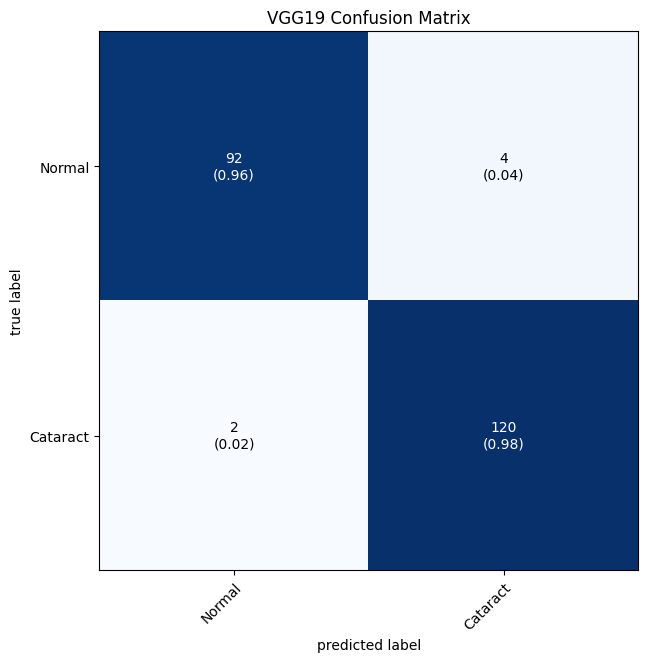

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


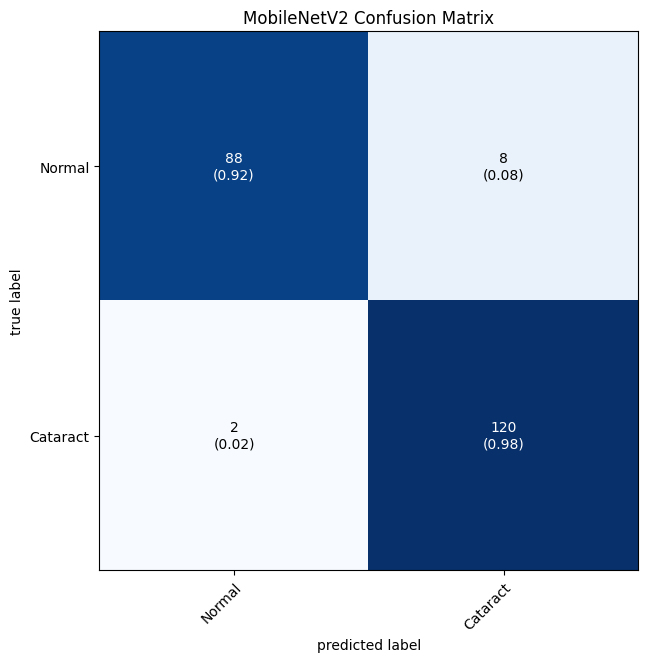

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


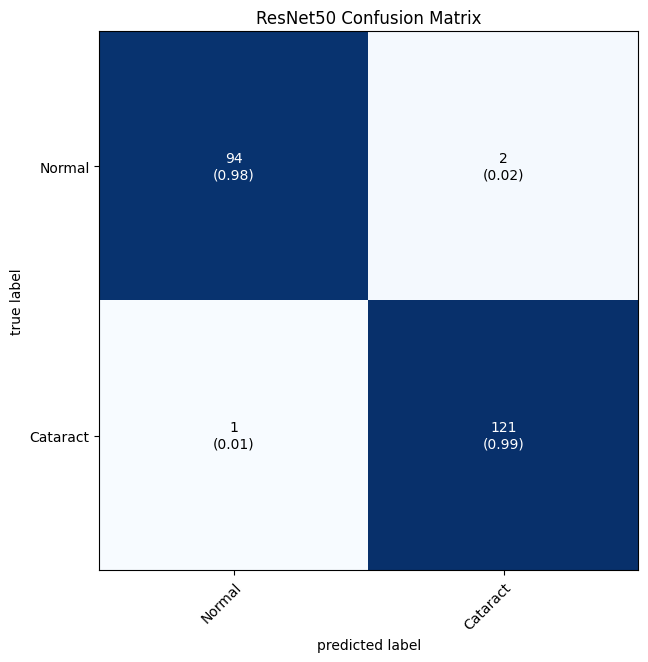

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

# --- VGG19 ---
y_pred_vgg19 = model.predict(x_test)
y_pred_vgg19 = (y_pred_vgg19 > 0.5).astype(int)
cm_vgg19 = confusion_matrix(y_test, y_pred_vgg19)
plot_confusion_matrix(conf_mat=cm_vgg19, figsize=(8, 7), class_names=["Normal", "Cataract"], show_normed=True)
plt.title("VGG19 Confusion Matrix")  # Add a title to the plot
plt.show()  # Display the plot


# --- MobileNetV2 ---
y_pred_mobilenet = mobilenet_model.predict(x_test)
y_pred_mobilenet = (y_pred_mobilenet > 0.5).astype(int)
cm_mobilenet = confusion_matrix(y_test, y_pred_mobilenet)
plot_confusion_matrix(conf_mat=cm_mobilenet, figsize=(8, 7), class_names=["Normal", "Cataract"], show_normed=True)
plt.title("MobileNetV2 Confusion Matrix")  # Add a title to the plot
plt.show()  # Display the plot


# --- ResNet50 ---
y_pred_resnet = resnet_model.predict(x_test)
y_pred_resnet = (y_pred_resnet > 0.5).astype(int)
cm_resnet = confusion_matrix(y_test, y_pred_resnet)
plot_confusion_matrix(conf_mat=cm_resnet, figsize=(8, 7), class_names=["Normal", "Cataract"], show_normed=True)
plt.title("ResNet50 Confusion Matrix")  # Add a title to the plot
plt.show()  # Display the plot

><h3>Learning Curve</h3>

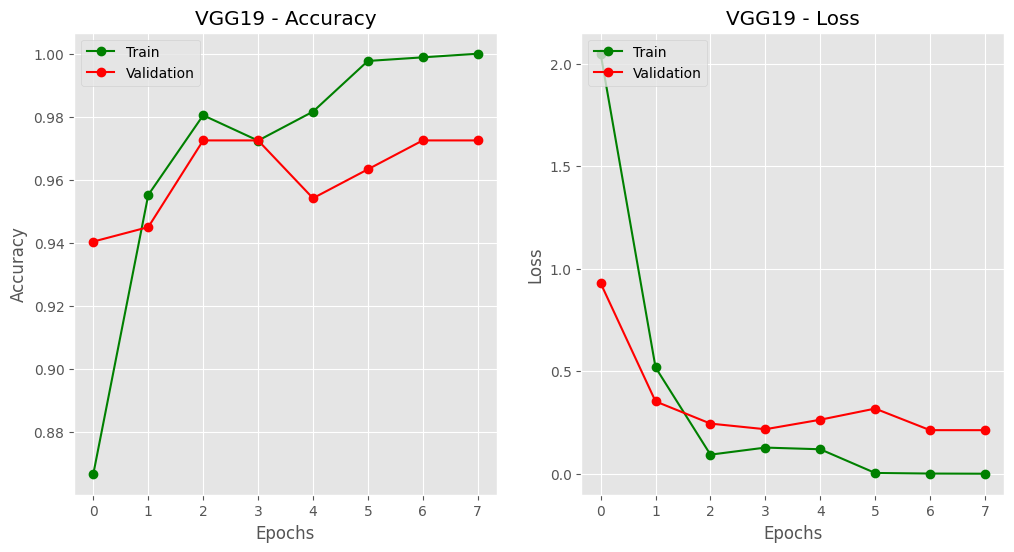

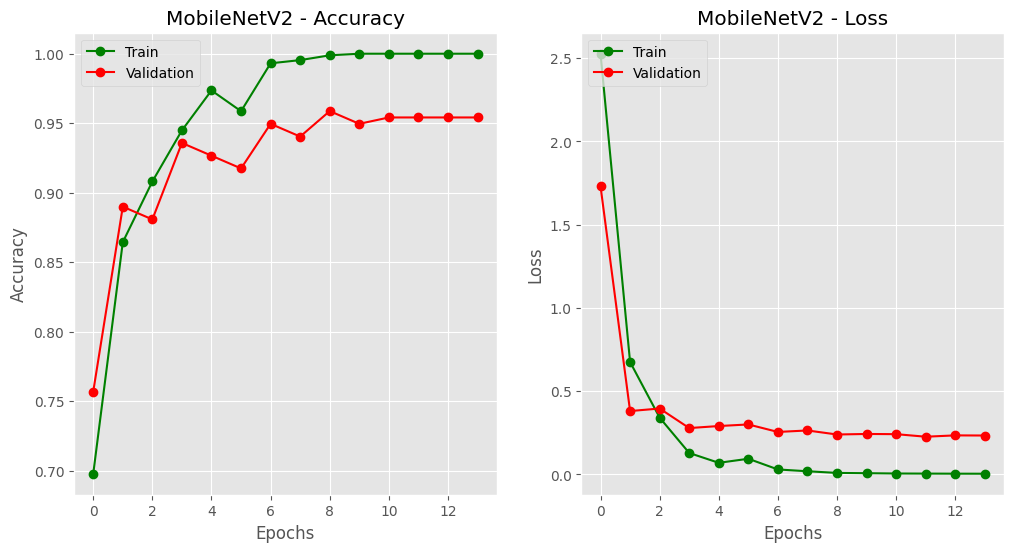

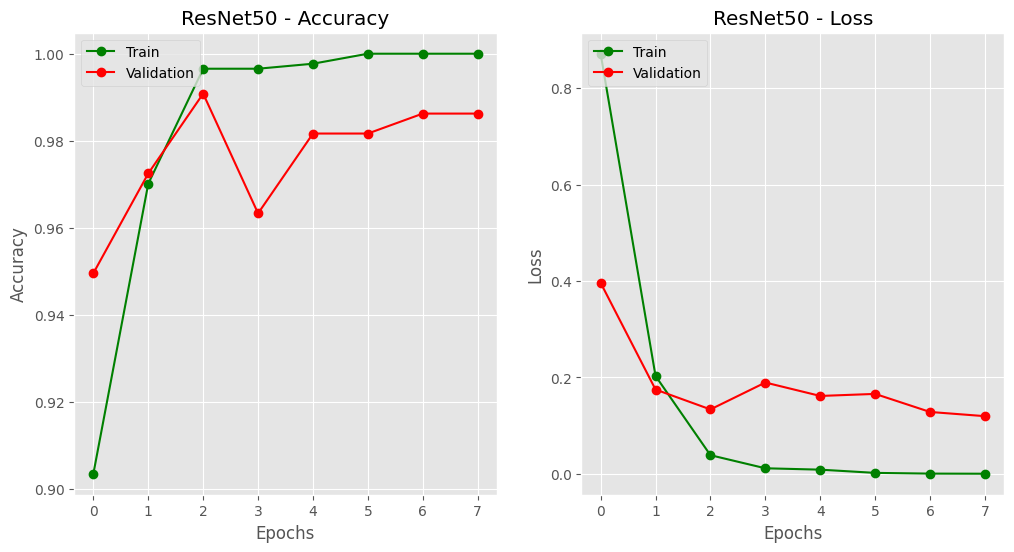

In [ ]:
import matplotlib.pyplot as plt

# --- VGG19 ---
plt.style.use("ggplot")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], "go-")
plt.plot(history.history["val_accuracy"], "ro-")
plt.title("VGG19 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="upper left")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], "go-")
plt.plot(history.history["val_loss"], "ro-")
plt.title("VGG19 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

# --- MobileNetV2 ---
plt.style.use("ggplot")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(mobilenet_history.history["accuracy"], "go-")
plt.plot(mobilenet_history.history["val_accuracy"], "ro-")
plt.title("MobileNetV2 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="upper left")

plt.subplot(1, 2, 2)
plt.plot(mobilenet_history.history["loss"], "go-")
plt.plot(mobilenet_history.history["val_loss"], "ro-")
plt.title("MobileNetV2 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

# --- ResNet50 ---
plt.style.use("ggplot")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history["accuracy"], "go-")
plt.plot(resnet_history.history["val_accuracy"], "ro-")
plt.title("ResNet50 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="upper left")

plt.subplot(1, 2, 2)
plt.plot(resnet_history.history["loss"], "go-")
plt.plot(resnet_history.history["val_loss"], "ro-")
plt.title("ResNet50 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

><h3>Prediction:</h3>

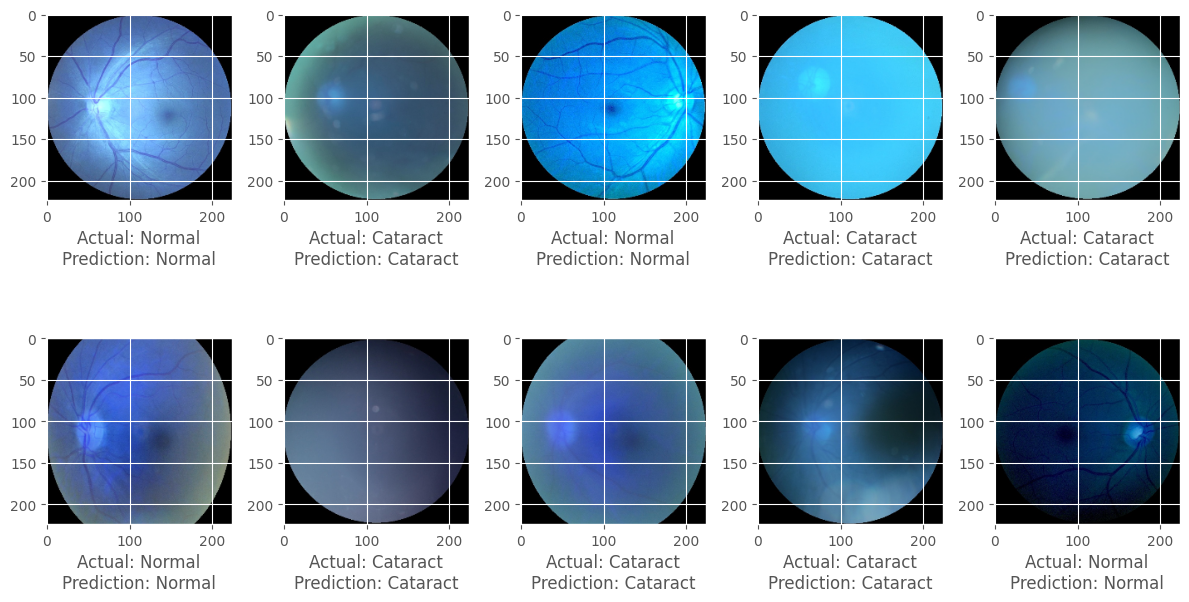

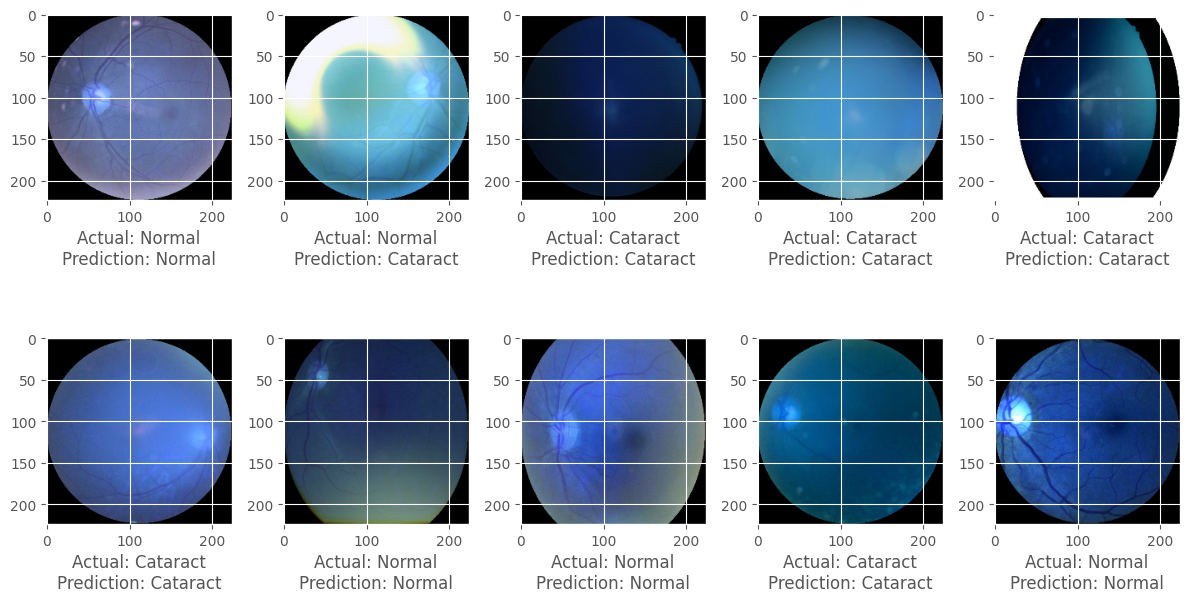

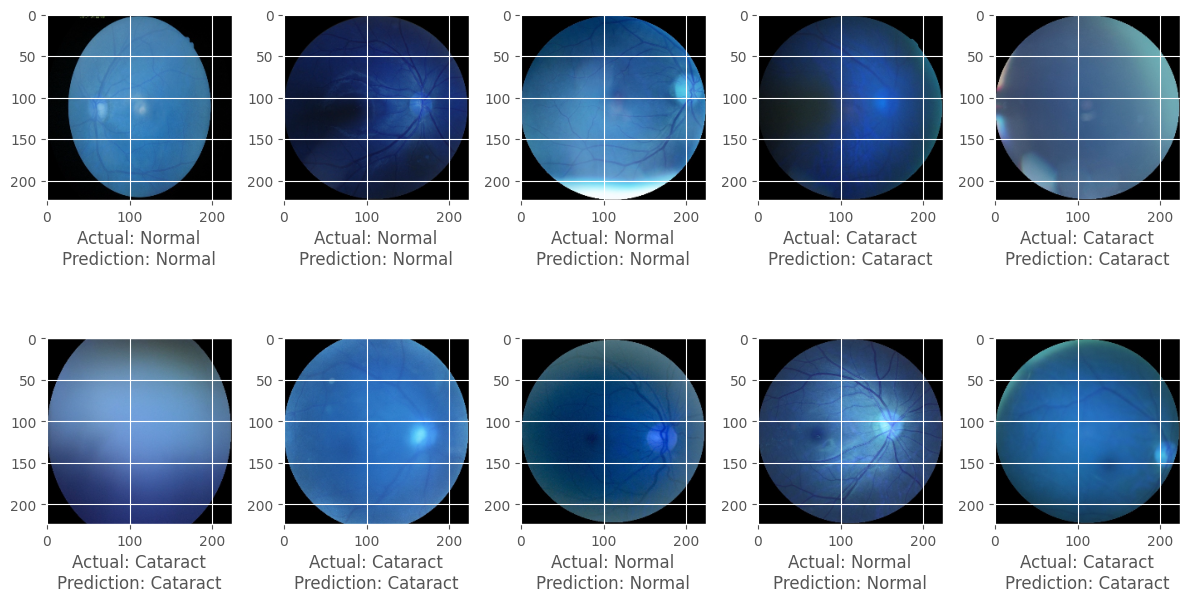

In [ ]:
import matplotlib.pyplot as plt
import random

# --- VGG19 ---
plt.figure(figsize=(12, 7))
for i in range(10):
    sample = random.choice(range(len(x_test)))
    image = x_test[sample]
    category = y_test[sample]
    pred_category = y_pred_vgg19[sample][0]  # Access the prediction for VGG19

    if category == 0:
        label = "Normal"
    else:
        label = "Cataract"

    if pred_category == 0:
        pred_label = "Normal"
    else:
        pred_label = "Cataract"

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel("Actual: {}\nPrediction: {}".format(label, pred_label))
plt.tight_layout()
plt.show()

# --- MobileNetV2 ---
plt.figure(figsize=(12, 7))
for i in range(10):
    sample = random.choice(range(len(x_test)))
    image = x_test[sample]
    category = y_test[sample]
    pred_category = y_pred_mobilenet[sample][0]  # Access the prediction for MobileNetV2

    # ... (rest of the code is the same as for VGG19) ...
    if category == 0:
        label = "Normal"
    else:
        label = "Cataract"

    if pred_category == 0:
        pred_label = "Normal"
    else:
        pred_label = "Cataract"

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel("Actual: {}\nPrediction: {}".format(label, pred_label))
plt.tight_layout()
plt.show()

# --- ResNet50 ---
plt.figure(figsize=(12, 7))
for i in range(10):
    sample = random.choice(range(len(x_test)))
    image = x_test[sample]
    category = y_test[sample]
    pred_category = y_pred_resnet[sample][0]  # Access the prediction for ResNet50

    # ... (rest of the code is the same as for VGG19) ...
    if category == 0:
        label = "Normal"
    else:
        label = "Cataract"

    if pred_category == 0:
        pred_label = "Normal"
    else:
        pred_label = "Cataract"

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel("Actual: {}\nPrediction: {}".format(label, pred_label))
plt.tight_layout()
plt.show()

---

<h1 style="text-align: center;font-size: 20px;">Thanks for Reading!!</h1>

---